In [1]:
# ---- Reproducibility
import random
import torch

#seed = 1234
#random.seed(seed)
#torch.manual_seed(seed)
#if torch.cuda.is_available():
#    torch.cuda.manual_seed_all(seed)


In [2]:


# ---- Parameters
n, p = 50, 40
noise_std = 0.1

# (Optional) choose device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Data generation (PyTorch)
# Use float64 to mirror NumPy defaults
u = torch.rand(n, dtype=torch.float64, device=device)          # length n
v = torch.rand(p, dtype=torch.float64, device=device)          # length p

# Rank-1 matrix via outer product
rank_1_matrix = torch.outer(u, v)                              # (n, p)

# Homoscedastic Gaussian noise
noise = noise_std * torch.randn(n, p, dtype=torch.float64, device=device)

noisy_matrix = rank_1_matrix + noise

# ---- Print (move to CPU for readability if needed)
print("Rank-1 Matrix (Outer Product):")
print(rank_1_matrix.cpu().numpy())

print("\nNoisy Matrix (with Homoscedastic Noise):")
print(noisy_matrix.cpu().numpy())


Rank-1 Matrix (Outer Product):
[[0.3288487  0.59581467 0.45295901 ... 0.54705435 0.39256618 0.39211148]
 [0.12131685 0.2198043  0.16710286 ... 0.20181594 0.14482311 0.14465536]
 [0.18828951 0.34114671 0.25935158 ... 0.31322792 0.22477234 0.224512  ]
 ...
 [0.28658837 0.51924656 0.39474927 ... 0.47675241 0.34211751 0.34172125]
 [0.33131696 0.60028671 0.45635881 ... 0.5511604  0.39551268 0.39505457]
 [0.00204198 0.0036997  0.00281264 ... 0.00339692 0.00243763 0.00243481]]

Noisy Matrix (with Homoscedastic Noise):
[[ 0.47129629  0.77537402  0.53393584 ...  0.59824098  0.44088592
   0.45762083]
 [-0.00577408  0.12239966  0.07001186 ...  0.25315695 -0.18063272
   0.27723728]
 [ 0.23794749  0.32627545  0.19766682 ...  0.19174734  0.33761421
   0.30532887]
 ...
 [ 0.38061849  0.53265902  0.36602866 ...  0.51178904  0.30572935
   0.16223332]
 [ 0.34206163  0.60727606  0.5668667  ...  0.46657236  0.40400872
   0.47673419]
 [-0.27882562  0.04631112 -0.01858836 ...  0.07334033 -0.03704431
  -0.21

In [3]:
import sys
import os
import matplotlib.pyplot as plt
from cebmf_torch import cEBMF

In [4]:
mycebmf=  cEBMF(data= noisy_matrix, prior_F="exp",
                prior_L="exp") 

 

In [5]:
mycebmf.initialise_factors()
print(mycebmf.L[:,1])
print(mycebmf.F[:,1])

tensor([-0.1230,  0.1358,  0.2423,  0.0562,  0.1266, -0.1830, -0.2101,  0.2008,
         0.1256,  0.1566, -0.0947,  0.2398,  0.2074,  0.0664, -0.0818, -0.1305,
        -0.0036,  0.0946,  0.1867, -0.2483,  0.1457, -0.1208,  0.0833,  0.2030,
         0.0286,  0.0677, -0.1245,  0.2307, -0.0715,  0.0113, -0.0901, -0.0429,
         0.2265, -0.3264, -0.1537,  0.2377, -0.0415, -0.2635,  0.0892,  0.2782,
         0.2387,  0.1705, -0.1331, -0.2717, -0.0680, -0.4670,  0.0118,  0.1072,
        -0.0520,  0.1262], dtype=torch.float64)
tensor([-0.0526, -0.1568, -0.0276,  0.0488, -0.3058, -0.3147, -0.2812, -0.0084,
         0.2985,  0.1248,  0.2331, -0.0587, -0.0348,  0.0868,  0.4642, -0.0625,
         0.0354, -0.0322,  0.1010,  0.1239,  0.0469,  0.2720,  0.0957, -0.1786,
         0.0480, -0.0797,  0.1903,  0.0619,  0.2473, -0.0471, -0.0291,  0.1540,
        -0.0923, -0.0245,  0.0284,  0.0630, -0.0238, -0.0928,  0.0256, -0.0436],
       dtype=torch.float64)


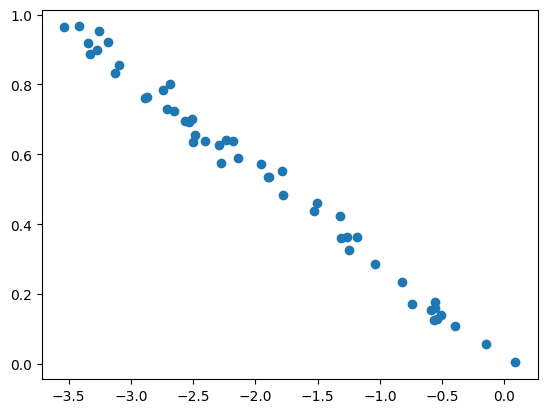

In [6]:
plt.scatter( mycebmf.L[:,0],u)

In [7]:
mycebmf.iter_once()
mycebmf._update_fitted_value()
import numpy as np
K=0
mycebmf.Y_fit 

tensor([[0.0211, 0.0382, 0.0318,  ..., 0.0303, 0.0243, 0.0237],
        [0.2067, 0.4634, 0.3146,  ..., 0.3953, 0.2899, 0.2785],
        [0.3090, 0.5803, 0.4874,  ..., 0.5178, 0.4188, 0.4005],
        ...,
        [0.3054, 0.6575, 0.4618,  ..., 0.5304, 0.3903, 0.3834],
        [0.0946, 0.1962, 0.1717,  ..., 0.1795, 0.1412, 0.1506],
        [0.1137, 0.2269, 0.1724,  ..., 0.1979, 0.1542, 0.1446]],
       dtype=torch.float64)

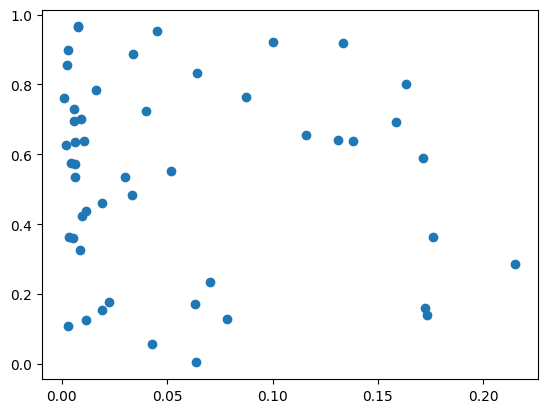

In [8]:
plt.scatter( mycebmf.L[:,0],u)

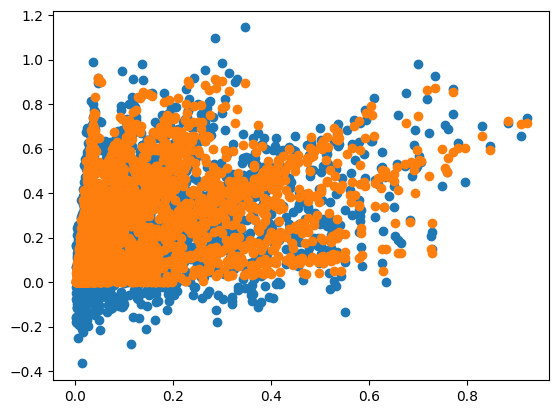

In [9]:
mycebmf.iter_once()  
plt.scatter(mycebmf.Y_fit, noisy_matrix)
 
plt.scatter(mycebmf.Y_fit, rank_1_matrix)

In [10]:
mycebmf.fit()

CEBMFResult(L=tensor([[0.2394, 0.0153],
        [0.0786, 0.0157],
        [0.1205, 0.0157],
        [0.1807, 0.0155],
        [0.2998, 0.0155],
        [0.2182, 0.0154],
        [0.1133, 0.0155],
        [0.2141, 0.0158],
        [0.0704, 0.0156],
        [0.2750, 0.0156],
        [0.3390, 0.0154],
        [0.0485, 0.0157],
        [0.2085, 0.0158],
        [0.1699, 0.0155],
        [0.1192, 0.0157],
        [0.2598, 0.0157],
        [0.2628, 0.0155],
        [0.3120, 0.0156],
        [0.2378, 0.0158],
        [0.0373, 0.0155],
        [0.0517, 0.0155],
        [0.1817, 0.0154],
        [0.2539, 0.0153],
        [0.3207, 0.0157],
        [0.0530, 0.0155],
        [0.3191, 0.0156],
        [0.1867, 0.0157],
        [0.2574, 0.0154],
        [0.2402, 0.0153],
        [0.1438, 0.0154],
        [0.3273, 0.0156],
        [0.0534, 0.0157],
        [0.2429, 0.0153],
        [0.2196, 0.0153],
        [0.1251, 0.0156],
        [0.2049, 0.0155],
        [0.1459, 0.0156],
        [0.3140, 0.0156]

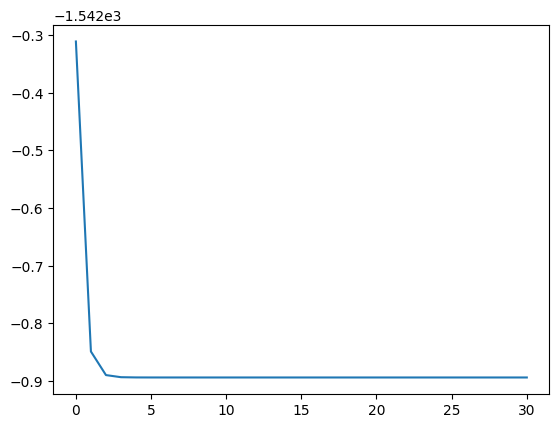

In [11]:
plt.plot(mycebmf.obj)

tensor(0.0936, dtype=torch.float64)

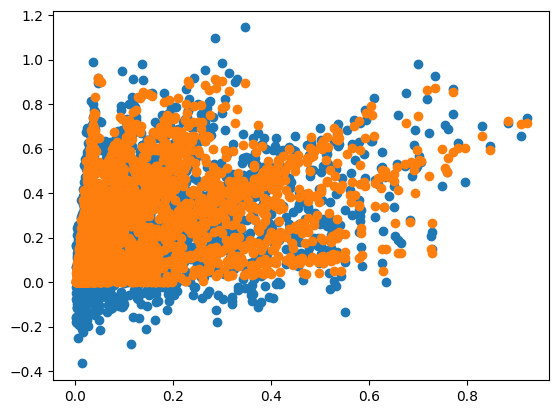

In [12]:
plt.scatter(mycebmf.Y_fit, noisy_matrix)
 
plt.scatter(mycebmf.Y_fit, rank_1_matrix)
torch.sqrt(torch.mean(mycebmf.Y_fit- rank_1_matrix)**2)

In [23]:
results =[]
for i in range(50):
    # Parameters
    n, p = 50, 40
    noise_std = 0.1

# (Optional) choose device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Data generation (PyTorch)
# Use float64 to mirror NumPy defaults
    u = torch.rand(n, dtype=torch.float64, device=device)          # length n
    v = torch.rand(p, dtype=torch.float64, device=device)          # length p

# Rank-1 matrix via outer product
    rank_1_matrix = torch.outer(u, v)                              # (n, p)

# Homoscedastic Gaussian noise
    noise = noise_std * torch.randn(n, p, dtype=torch.float64, device=device)

    noisy_matrix = rank_1_matrix + noise

 
# Add homoscedastic Gaussian noise (constant variance across the matrix)
    mycebmf=  cEBMF(data= noisy_matrix,prior_L="exp",
                    prior_F="exp") 
    mycebmf.initialise_factors()
    mycebmf.fit()
    
    mycebmf._update_fitted_value()
    
    rr = torch.sqrt(torch.mean((mycebmf.Y_fit- rank_1_matrix)**2))
    results.append( rr)
    res= np.asarray(results)
    print(np.mean(res ))
 

0.021276582668826375
0.020470708852898346
0.02044806034502913
0.02040153817823334
0.020170435263266263
0.020012651206571395
0.02030770743931008
0.02016417539967142
0.02016974995738362
0.020188730050198295
0.020459879845365
0.02061684009495369
0.020690344850652628
0.020712551424182917
0.020727725283263988
0.02076411488874437
0.020793496701636147
0.020858978997990964
0.02089228695992398
0.02095133665289472
0.02087643057805317
0.02083735500376582
0.02073156047059657
0.020777093120155705
0.020744933151857166
0.02072945936686791
0.020725200565310863
0.02076406803444222
0.02077153154783479
0.02066966245995657
0.020648977636313116
0.020578797043156627
0.02066744137609391
0.02072145591932852
0.02074257853087463
0.020750064183909275
0.02069952736141139
0.020625745275954434
0.020605509157091976
0.02061041137888771
0.02060185518196912
0.02061974398935725
0.020607635966444396
0.02065682918071592
0.02072013737604962
0.02075717902385995
0.020714477649608758
0.02072705900662445
0.020719881403612004
0

In [14]:
i


49

In [24]:
results

[tensor(0.0213, dtype=torch.float64),
 tensor(0.0197, dtype=torch.float64),
 tensor(0.0204, dtype=torch.float64),
 tensor(0.0203, dtype=torch.float64),
 tensor(0.0192, dtype=torch.float64),
 tensor(0.0192, dtype=torch.float64),
 tensor(0.0221, dtype=torch.float64),
 tensor(0.0192, dtype=torch.float64),
 tensor(0.0202, dtype=torch.float64),
 tensor(0.0204, dtype=torch.float64),
 tensor(0.0232, dtype=torch.float64),
 tensor(0.0223, dtype=torch.float64),
 tensor(0.0216, dtype=torch.float64),
 tensor(0.0210, dtype=torch.float64),
 tensor(0.0209, dtype=torch.float64),
 tensor(0.0213, dtype=torch.float64),
 tensor(0.0213, dtype=torch.float64),
 tensor(0.0220, dtype=torch.float64),
 tensor(0.0215, dtype=torch.float64),
 tensor(0.0221, dtype=torch.float64),
 tensor(0.0194, dtype=torch.float64),
 tensor(0.0200, dtype=torch.float64),
 tensor(0.0184, dtype=torch.float64),
 tensor(0.0218, dtype=torch.float64),
 tensor(0.0200, dtype=torch.float64),
 tensor(0.0203, dtype=torch.float64),
 tensor(0.02

In [25]:
res= np.asarray(results)
np.mean(res )

np.float64(0.020724951026847335)

In [26]:
np.sqrt(np.var(res ))

np.float64(0.001376099227251401)

In [27]:
import numpy as np
import matplotlib.pyplot as plt

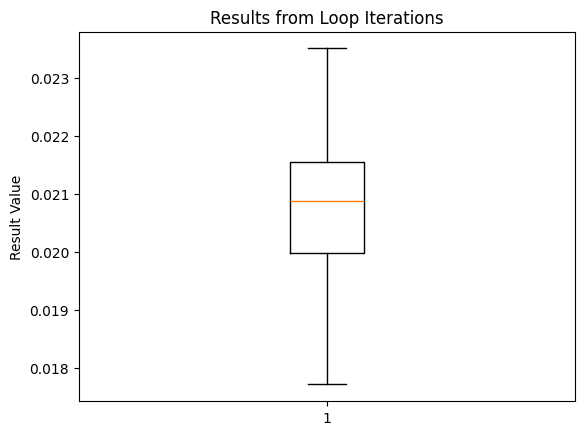

In [28]:
plt.boxplot(results)
plt.title("Results from Loop Iterations")
plt.ylabel("Result Value")
plt.show()

In [29]:
res= np.asarray(results)
np.mean(res )

np.float64(0.020724951026847335)

In [30]:
np.sqrt(np.var(res ))

np.float64(0.001376099227251401)

tensor(0.0011, dtype=torch.float64)

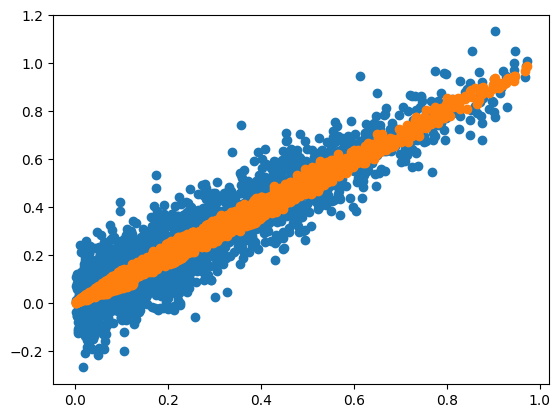

In [31]:
mycebmf._update_fitted_value()
plt.scatter(mycebmf.Y_fit, noisy_matrix)
 
plt.scatter(mycebmf.Y_fit, rank_1_matrix)
torch.sqrt(torch.mean(mycebmf.Y_fit- rank_1_matrix)**2)